# 설비 이미지 기반 질의응답 실습

**설비(컨베이어 벨트) 이미지**를 대상으로 텍스트·이미지 질의 → 유사 프레임 검색 → 센서 연계 → Qwen3-VL 답변까지
**이미지 기반 질의응답(VQA)** 을 단계별로 실습합니다.

> **선행 학습**: `02_conveyor_belt_visual_rag.ipynb`(인덱스) · `03_analysis_vectordb_api_deploy.ipynb`(API) · `04_visual_qa_service_streamlit.ipynb`(서비스 UI)

## 전체 흐름

```
04 노트북 (Streamlit + FastAPI 서비스)
       ↓
설비 프레임·센서 데이터 탐색
       ↓
텍스트 질의 → SigLIP2 → ChromaDB 검색
       ↓
이미지 질의 → SigLIP2 → 유사 설비 프레임 검색  ← 이번 실습 핵심
       ↓
특정 프레임 직접 VQA (Qwen3-VL)
       ↓
Visual RAG 종합 분석 + 시각·센서 교차 검증
```

| 질의 유형 | 입력 | 검색 방식 | 활용 예 |
|------|------|----------|---------|
| **텍스트 질의** | "벨트 이상 상태" | `encode_texts` | 자연어로 관련 프레임 탐색 |
| **이미지 질의** | `frame0004.jpg` | `encode_images` | 참조 이미지로 유사 이상 탐색 |
| **직접 VQA** | 프레임 + 질문 | 검색 없음 | "이 이미지에서 손상이 보이나?" |

### 설비 이미지 VQA란?

- **설비 이미지**: 공장·라인에서 촬영한 컨베이어 벨트 등 **설비 상태 사진(프레임)**.
- **질의응답**: 질문에 맞는 이미지를 찾거나, 특정 이미지에 대해 VLM이 **시각적 근거**로 답변합니다.
- 이 실습은 `conveyor_rag` 모듈을 **노트북에서 직접** 호출해 검색·분석 원리를 익힙니다.


### 모듈 소스 참조

📄 **[00_모듈_참조.md](00_모듈_참조.md)** — 경로별 파일 목록 + 기능 요약

| 노트북에서 직접 import | 경로 |
|------------------------|------|
| `SigLIP2Encoder` | `conveyor_analyze/conveyor_rag/encoder.py` |
| `ChromaStore` | `conveyor_analyze/conveyor_rag/store.py` |
| `QwenAnalyzer` | `conveyor_analyze/conveyor_rag/analyzer.py` |
| `enrich_hits_with_sensor` | `conveyor_analyze/conveyor_rag/metadata_link.py` |
| `plot_utils` | `conveyor_analyze/conveyor_rag/plot_utils.py` |
| FastAPI (선택) | `conveyor_analyze/api/main.py` |


## 0. 환경 설정

| 기술 | 역할 |
|------|------|
| **SigLIP2** | 텍스트·이미지를 동일 벡터 공간으로 매핑 |
| **ChromaDB** | 설비 프레임 임베딩 저장·검색 |
| **sensor.csv** | 프레임별 temp/rpm/vibration/status |
| **Qwen3-VL** | 설비 이미지 + 센서 종합 답변 |
| **requests** | (선택) FastAPI `/analyze` 호출 |

**사전 준비**
<br>
1. `02` 노트북으로 `data/conveyor/frames`, `chroma_db` 생성<br>
2. `conveyor_analyze` 폴더 준비<br>
3. Qwen3-VL 분석 실습 시 GPU 권장 (또는 FastAPI 서버 실행)<br>

> 검색 실습(섹션 1~4)은 **API 없이** 모듈만으로 실행 가능합니다.


In [1]:
# !pip install -r conveyor_analyze/requirements.txt
# 선행: 02 노트북 + conveyor_analyze 폴더


In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import Markdown, display
from PIL import Image

ROOT = Path(".").resolve()
DATA_DIR = ROOT / "data" / "conveyor"
FRAMES_DIR = DATA_DIR / "frames"
CHROMA_DIR = DATA_DIR / "chroma_db"
SENSOR_CSV = DATA_DIR / "sensor.csv"
CONVEYOR_ANALYZE = ROOT / "conveyor_analyze"
API_BASE = "http://127.0.0.1:8000"

sys.path.insert(0, str(CONVEYOR_ANALYZE))

from conveyor_rag.encoder import SigLIP2Encoder
from conveyor_rag.store import ChromaStore
from conveyor_rag.metadata_link import build_frame_sensor_table, enrich_hits_with_sensor
from conveyor_rag.sensor import get_sensor_by_frame
from conveyor_rag.plot_utils import setup_korean_matplotlib

_korean_font = setup_korean_matplotlib()

API_TIMEOUT_ANALYZE = 900

if not FRAMES_DIR.exists() or not list(FRAMES_DIR.glob("frame*.jpg")):
    raise FileNotFoundError("02 노트북을 먼저 실행해 data/conveyor/frames 를 생성하세요.")
if not CHROMA_DIR.exists():
    raise FileNotFoundError("ChromaDB 없음 — 02 노트북 인덱싱을 먼저 실행하세요.")

print(f"ROOT: {ROOT}")
print(f"프레임: {len(list(FRAMES_DIR.glob('frame*.jpg')))}장")
print(f"ChromaDB: {CHROMA_DIR}")


def plot_search_hits(hits, title="검색 결과", max_cols=4):
    """검색 hit를 matplotlib으로 시각화."""
    n = min(len(hits), max_cols)
    if n == 0:
        print("검색 결과 없음")
        return None
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    rows = []
    for i, hit in enumerate(hits[:n]):
        meta = hit["metadata"]
        sensor = hit.get("sensor", meta)
        path = meta.get("local_path", "")
        ax = axes[i]
        if Path(path).exists():
            ax.imshow(Image.open(path))
        title_line = (
            f"{meta.get('frame')}\n"
            f"sim={hit['similarity']:.3f} | {sensor.get('status')}"
        )
        ax.set_title(title_line)
        ax.axis("off")
        rows.append({
            "frame": meta.get("frame"),
            "similarity": round(hit["similarity"], 3),
            "status": sensor.get("status"),
            "temp": sensor.get("temp"),
            "vibration": sensor.get("vibration"),
        })
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
    return pd.DataFrame(rows)


def search_by_text(encoder, store, query: str, top_k: int = 4):
    """텍스트 질의 → SigLIP2 → ChromaDB Top-k."""
    emb = encoder.encode_texts([query])[0]
    hits = store.search(emb.tolist(), top_k=top_k)
    return enrich_hits_with_sensor(hits)


def search_by_image(encoder, store, image_path: Path, top_k: int = 4, exclude_self: bool = True):
    """설비 이미지 질의 → 유사 프레임 검색."""
    img = Image.open(image_path).convert("RGB")
    emb = encoder.encode_images([img])[0]
    fetch_k = top_k + 1 if exclude_self else top_k
    hits = store.search(emb.tolist(), top_k=fetch_k)
    if exclude_self:
        query_name = image_path.name
        hits = [h for h in hits if h["metadata"].get("frame") != query_name]
        hits = hits[:top_k]
    return enrich_hits_with_sensor(hits)


def check_api():
    try:
        r = requests.get(f"{API_BASE}/", timeout=5)
        r.raise_for_status()
        return r.json()
    except (requests.ConnectionError, requests.ReadTimeout):
        return None


encoder = SigLIP2Encoder()
store = ChromaStore()
print(f"ChromaDB 벡터 수: {store.count()}")


ROOT: C:\MyCursorLab\09_Visual_RAG
프레임: 20장
ChromaDB: C:\MyCursorLab\09_Visual_RAG\data\conveyor\chroma_db


[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

ChromaDB 벡터 수: 20


## 1. 설비 이미지·센서 데이터 탐색

질의응답 전에 **설비 프레임**과 **가상 센서** 분포를 확인합니다.
Fault 상태 프레임이 이상 징후 학습·검증의 기준점이 됩니다.


,frame,image_path,machine,temp,rpm,vibration,current,speed,status
0,frame0001.jpg,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...,M01,38.2,1150,0.08,2.9,0.95,Normal
1,frame0002.jpg,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...,M01,39.1,1170,0.10,3.0,0.95,Normal
2,frame0003.jpg,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...,M01,45.3,1230,0.31,3.8,0.96,Warning
3,frame0004.jpg,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...,M01,48.8,1260,0.45,4.1,0.98,Fault
4,frame0005.jpg,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...,M01,49.3,1261,0.47,4.1,0.98,Fault
5,frame0006.jpg,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...,M01,49.9,1270,0.51,4.2,0.98,Fault
6,frame0007.jpg,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...,M01,49.9,1265,0.49,4.3,0.98,Fault
7,frame0008.jpg,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...,M01,49.5,1270,0.55,4.4,0.99,Warning



상태별 프레임 수:
status
Warning    9
Fault      9
Normal     2


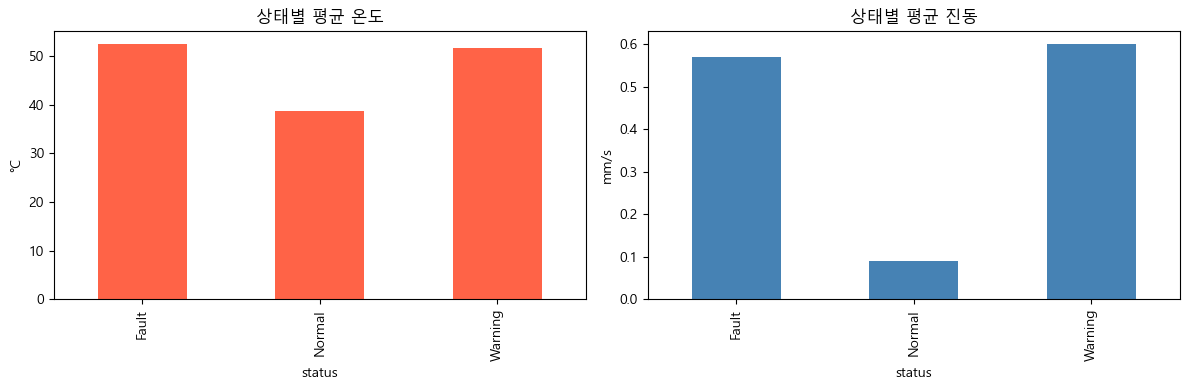

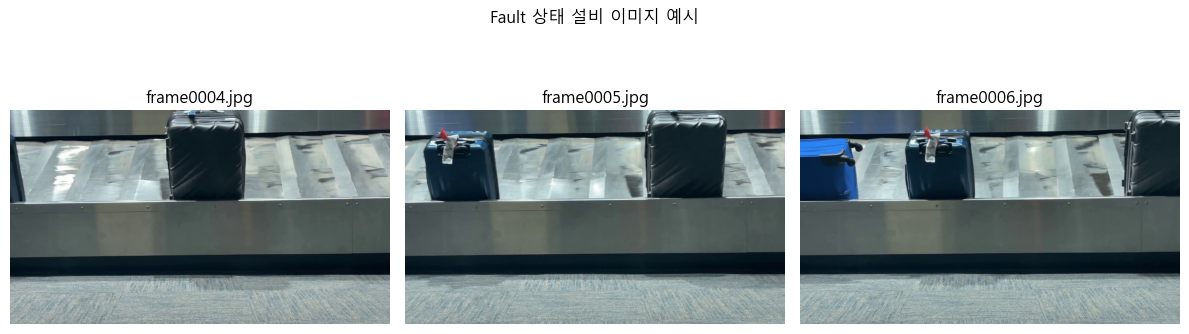

In [3]:
frame_table = build_frame_sensor_table(FRAMES_DIR, SENSOR_CSV)
display(frame_table.head(8))

status_counts = frame_table["status"].value_counts()
print("\n상태별 프레임 수:")
print(status_counts.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
frame_table.groupby("status")["temp"].mean().plot(kind="bar", ax=axes[0], color="tomato")
axes[0].set_title("상태별 평균 온도")
axes[0].set_ylabel("°C")
frame_table.groupby("status")["vibration"].mean().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("상태별 평균 진동")
axes[1].set_ylabel("mm/s")
plt.tight_layout()
plt.show()

fault_frames = frame_table[frame_table["status"] == "Fault"]["frame"].head(3).tolist()
fig, axes = plt.subplots(1, len(fault_frames), figsize=(4 * len(fault_frames), 4))
if len(fault_frames) == 1:
    axes = [axes]
for ax, fname in zip(axes, fault_frames):
    ax.imshow(Image.open(FRAMES_DIR / fname))
    ax.set_title(fname)
    ax.axis("off")
plt.suptitle("Fault 상태 설비 이미지 예시")
plt.tight_layout()
plt.show()


## 2. 텍스트 질의 — 관련 설비 이미지 검색

자연어 질문을 SigLIP2 텍스트 임베딩으로 변환한 뒤 ChromaDB에서 **의미적으로 가까운 프레임**을 찾습니다.

```
"컨베이어 벨트 이상 상태"  →  encode_texts  →  Top-k 프레임
```


텍스트 질의: 컨베이어 벨트 이상 상태


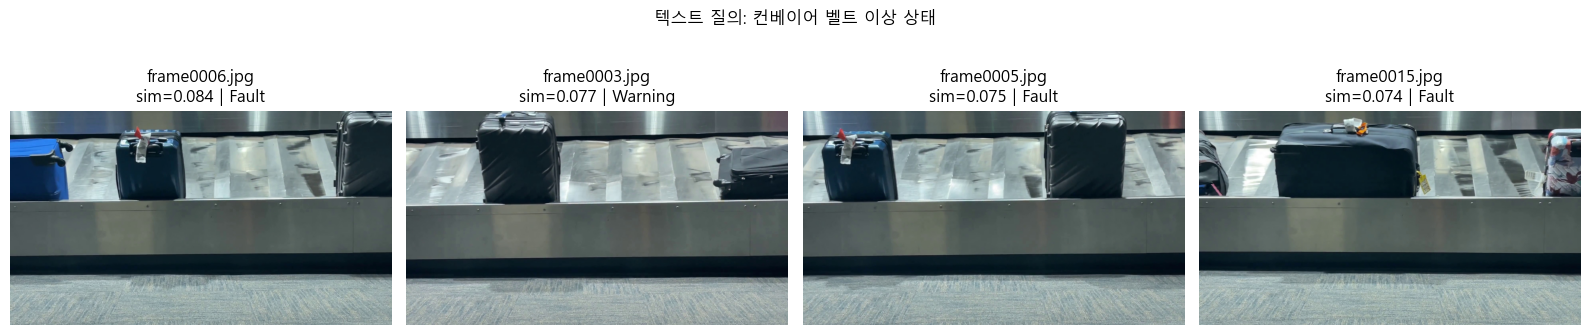

,frame,similarity,status,temp,vibration
0,frame0006.jpg,0.084,Fault,49.9,0.51
1,frame0003.jpg,0.077,Warning,45.3,0.31
2,frame0005.jpg,0.075,Fault,49.3,0.47
3,frame0015.jpg,0.074,Fault,56.1,0.78


In [4]:
TEXT_QUERY = "컨베이어 벨트 이상 상태"
TOP_K = 4

text_hits = search_by_text(encoder, store, TEXT_QUERY, top_k=TOP_K)
print(f"텍스트 질의: {TEXT_QUERY}")
text_result_df = plot_search_hits(text_hits, title=f"텍스트 질의: {TEXT_QUERY}")
display(text_result_df)


## 3. 이미지 질의 — 유사 설비 프레임 검색

**이번 실습의 핵심** — 참조 설비 이미지를 쿼리로 넣어 비슷한 상태의 프레임을 검색합니다.

```
frame0004.jpg (Fault)  →  encode_images  →  유사 이상 프레임 Top-k
```

> 현장에서는 "이 사진과 비슷한 과거 이력이 있나?" 형태로 활용할 수 있습니다.


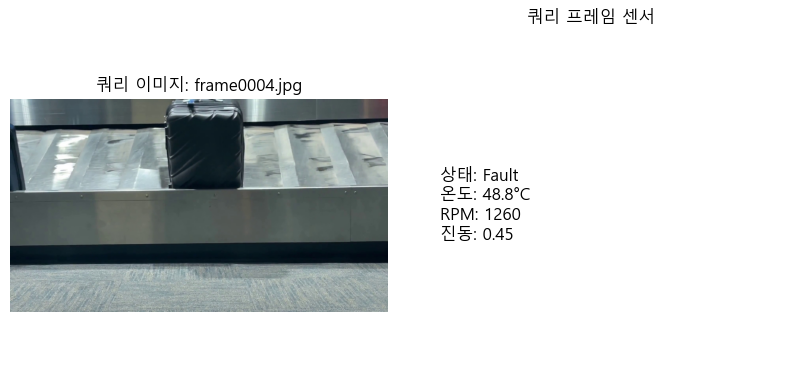


이미지 질의: frame0004.jpg


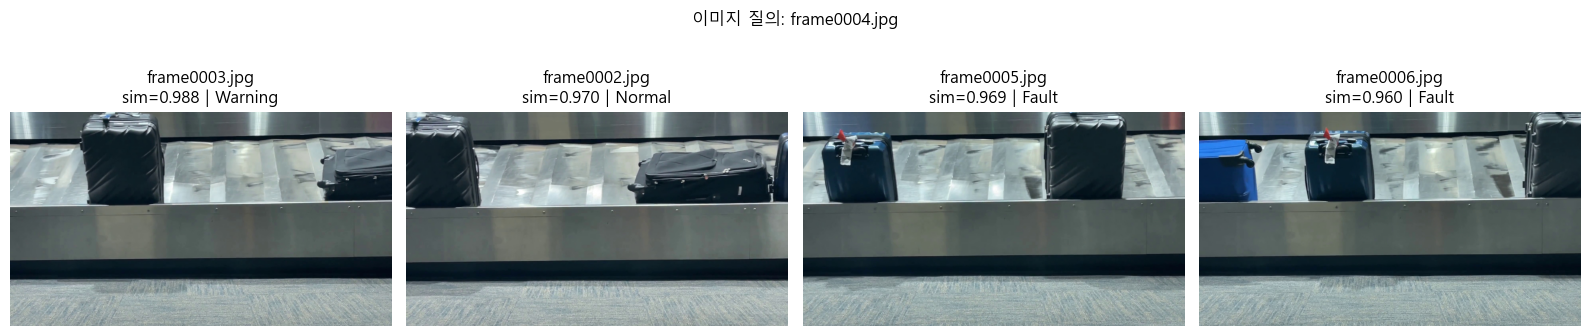

,frame,similarity,status,temp,vibration
0,frame0003.jpg,0.988,Warning,45.3,0.31
1,frame0002.jpg,0.970,Normal,39.1,0.10
2,frame0005.jpg,0.969,Fault,49.3,0.47
3,frame0006.jpg,0.960,Fault,49.9,0.51


In [5]:
QUERY_FRAME = "frame0004.jpg"
query_path = FRAMES_DIR / QUERY_FRAME

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(Image.open(query_path))
axes[0].set_title(f"쿼리 이미지: {QUERY_FRAME}")
axes[0].axis("off")
sensor_q = get_sensor_by_frame(QUERY_FRAME)
axes[1].axis("off")
sensor_text = (
    f"상태: {sensor_q.get('status')}\n"
    f"온도: {sensor_q.get('temp')}°C\n"
    f"RPM: {sensor_q.get('rpm')}\n"
    f"진동: {sensor_q.get('vibration')}"
)
axes[1].text(0.1, 0.5, sensor_text, fontsize=12, va="center")
axes[1].set_title("쿼리 프레임 센서")
plt.tight_layout()
plt.show()

image_hits = search_by_image(encoder, store, query_path, top_k=TOP_K)
print(f"\n이미지 질의: {QUERY_FRAME}")
image_result_df = plot_search_hits(image_hits, title=f"이미지 질의: {QUERY_FRAME}")
display(image_result_df)


## 4. 텍스트 vs 이미지 질의 비교

동일한 설비 상황을 **텍스트**와 **이미지**로 질의했을 때 검색 결과가 어떻게 다른지 비교합니다.


In [6]:
compare_text = "벨트 과열 및 진동 이상"
compare_image = FRAMES_DIR / "frame0013.jpg"

hits_text = search_by_text(encoder, store, compare_text, top_k=3)
hits_image = search_by_image(encoder, store, compare_image, top_k=3)

print("=== 텍스트 질의 ===")
print(compare_text)
for h in hits_text:
    s = h.get("sensor", h["metadata"])
    print(f"  {s.get('frame')}: sim={h['similarity']:.3f}, status={s.get('status')}")

print("\n=== 이미지 질의 ===")
print(compare_image.name)
for h in hits_image:
    s = h.get("sensor", h["metadata"])
    print(f"  {s.get('frame')}: sim={h['similarity']:.3f}, status={s.get('status')}")

frames_text = {h["metadata"]["frame"] for h in hits_text}
frames_image = {h["metadata"]["frame"] for h in hits_image}
overlap = frames_text & frames_image
print(f"\n공통 검색 프레임: {overlap or '없음'}")


=== 텍스트 질의 ===
벨트 과열 및 진동 이상
  frame0001.jpg: sim=0.065, status=Normal
  frame0019.jpg: sim=0.061, status=Warning
  frame0006.jpg: sim=0.061, status=Fault

=== 이미지 질의 ===
frame0013.jpg
  frame0012.jpg: sim=0.977, status=Warning
  frame0014.jpg: sim=0.971, status=Fault
  frame0011.jpg: sim=0.971, status=Warning

공통 검색 프레임: 없음


## 5. 특정 설비 이미지 직접 질의응답

검색 없이 **한 장의 설비 이미지**에 대해 Qwen3-VL이 직접 답변합니다.

| 항목 | 권장값 |
|------|--------|
| `RUN_DIRECT_VQA` | `False` (GPU·시간 절약) / `True`로 직접 실행 |
| 소요 시간 | GPU 기준 프레임 1장당 약 1~3분 |


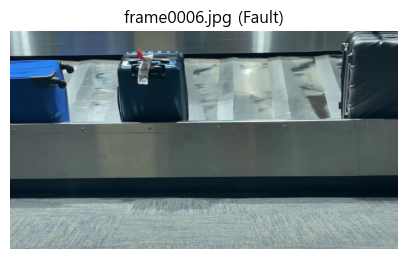

**센서**: temp=49.9°C, rpm=1270, vibration=0.51, status=Fault

**질문**: 이 컨베이어 벨트 설비 이미지에서 이상 징후가 보이나요? 손상·이물질·벨트 정렬 이상을 설명하세요.

RUN_DIRECT_VQA = True 로 설정하면 Qwen3-VL 직접 VQA를 실행합니다.
또는 아래 섹션 6에서 FastAPI /analyze 를 사용하세요.


In [7]:
RUN_DIRECT_VQA = False

TARGET_FRAME = "frame0006.jpg"
VQA_QUESTION = (
    "이 컨베이어 벨트 설비 이미지에서 이상 징후가 보이나요? "
    "손상·이물질·벨트 정렬 이상을 설명하세요."
)

target_path = FRAMES_DIR / TARGET_FRAME
sensor_row = get_sensor_by_frame(TARGET_FRAME)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(Image.open(target_path))
ax.set_title(f"{TARGET_FRAME} ({sensor_row.get('status')})")
ax.axis("off")
plt.show()

display(Markdown(
    f"**센서**: temp={sensor_row.get('temp')}°C, "
    f"rpm={sensor_row.get('rpm')}, vibration={sensor_row.get('vibration')}, "
    f"status={sensor_row.get('status')}"
))
display(Markdown(f"**질문**: {VQA_QUESTION}"))

if RUN_DIRECT_VQA:
    from conveyor_rag.analyzer import QwenAnalyzer

    encoder.unload()
    analyzer = QwenAnalyzer()
    prompt = (
        f"{VQA_QUESTION}\n\n"
        f"[센서] temp={sensor_row['temp']}°C, rpm={sensor_row['rpm']}, "
        f"vibration={sensor_row['vibration']}, status={sensor_row['status']}"
    )
    answer = analyzer.run_vl([str(target_path)], prompt, max_new_tokens=150)
    display(Markdown(f"### Qwen3-VL 답변\n\n{answer}"))
else:
    print("RUN_DIRECT_VQA = True 로 설정하면 Qwen3-VL 직접 VQA를 실행합니다.")
    print("또는 아래 섹션 6에서 FastAPI /analyze 를 사용하세요.")


## 6. Visual RAG 종합 질의응답

검색 + 센서 + Qwen3-VL을 한 번에 실행하는 **Visual RAG** 파이프라인입니다.
`04` 노트북·Streamlit 분석 탭과 동일한 `POST /analyze` API를 호출합니다.


In [8]:
RUN_ANALYZE = False
ANALYZE_QUERY = (
    "컨베이어 벨트에서 이상 징후가 보이는 프레임을 찾고 원인과 조치를 분석하세요."
)

if RUN_ANALYZE and check_api():
    print(f"/analyze 호출 중... (최대 {API_TIMEOUT_ANALYZE}초)")
    r = requests.post(
        f"{API_BASE}/analyze",
        json={"query": ANALYZE_QUERY, "top_k": 2, "save_history": True},
        timeout=API_TIMEOUT_ANALYZE,
    )
    r.raise_for_status()
    result = r.json()

    frames = result.get("retrieved_frames", [])
    if frames:
        n = min(len(frames), 4)
        fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
        if n == 1:
            axes = [axes]
        for i, frame in enumerate(frames[:n]):
            axes[i].imshow(Image.open(FRAMES_DIR / frame))
            axes[i].set_title(frame)
            axes[i].axis("off")
        plt.suptitle("Visual RAG 검색 프레임")
        plt.tight_layout()
        plt.show()

    display(Markdown("### 센서 데이터"))
    display(pd.DataFrame(result.get("sensor_data", [])))
    display(Markdown(f"### Qwen3-VL 분석\n\n{result.get('analysis', '')}"))
elif RUN_ANALYZE:
    print("API 서버를 먼저 실행하세요.")
    print("  cd conveyor_analyze")
    print("  python scripts/run_api.py")
else:
    print("RUN_ANALYZE = True 로 설정하면 Visual RAG 종합 분석을 실행합니다.")


RUN_ANALYZE = True 로 설정하면 Visual RAG 종합 분석을 실행합니다.


## 7. 시각·센서 교차 검증

검색된 프레임의 **시각 유사도**와 **센서 status**가 일치하는지 확인합니다.


In [9]:
def cross_validate_hits(hits, label="검색 결과"):
    rows = []
    for hit in hits:
        sensor = hit.get("sensor", hit["metadata"])
        rows.append({
            "frame": sensor.get("frame"),
            "similarity": round(hit["similarity"], 3),
            "status": sensor.get("status"),
            "temp": sensor.get("temp"),
            "vibration": sensor.get("vibration"),
            "fault_match": sensor.get("status") in ("Fault", "Warning"),
        })
    df = pd.DataFrame(rows)
    n_fault = int(df["fault_match"].sum())
    fault_ratio = df["fault_match"].mean() if len(df) else 0
    print(f"[{label}] Fault/Warning 비율: {fault_ratio:.0%} ({n_fault}/{len(df)})")
    return df

cv_text = cross_validate_hits(text_hits, "텍스트 질의")
cv_image = cross_validate_hits(image_hits, "이미지 질의")
display(cv_text)
display(cv_image)


[텍스트 질의] Fault/Warning 비율: 100% (4/4)
[이미지 질의] Fault/Warning 비율: 75% (3/4)


,frame,similarity,status,temp,vibration,fault_match
0,frame0006.jpg,0.084,Fault,49.9,0.51,True
1,frame0003.jpg,0.077,Warning,45.3,0.31,True
2,frame0005.jpg,0.075,Fault,49.3,0.47,True
3,frame0015.jpg,0.074,Fault,56.1,0.78,True


,frame,similarity,status,temp,vibration,fault_match
0,frame0003.jpg,0.988,Warning,45.3,0.31,True
1,frame0002.jpg,0.970,Normal,39.1,0.10,False
2,frame0005.jpg,0.969,Fault,49.3,0.47,True
3,frame0006.jpg,0.960,Fault,49.9,0.51,True


## 8. 실무 진단 시나리오 실습

현장에서 자주 쓰는 **설비 이미지 질의응답** 패턴을 실행합니다.


In [10]:
SCENARIOS = [
    {"name": "이상 징후 탐지", "query": "벨트 표면에 이물질이나 손상이 보이나?", "mode": "text"},
    {"name": "과열 구간 탐색", "query": "온도가 높아 보이는 구간은 어디인가?", "mode": "text"},
    {"name": "유사 이상 이력 검색", "query": None, "mode": "image", "image": "frame0015.jpg"},
    {"name": "Fault 패턴 비교", "query": "Fault 상태와 유사한 프레임을 찾아라", "mode": "text"},
]

for i, scenario in enumerate(SCENARIOS, 1):
    print("=" * 50)
    print(f"시나리오 {i}: {scenario['name']}")
    if scenario["mode"] == "text":
        hits = search_by_text(encoder, store, scenario["query"], top_k=3)
        print(f"  질의(텍스트): {scenario['query']}")
    else:
        img_path = FRAMES_DIR / scenario["image"]
        hits = search_by_image(encoder, store, img_path, top_k=3)
        print(f"  질의(이미지): {scenario['image']}")
    for h in hits:
        s = h.get("sensor", h["metadata"])
        print(
            f"    -> {s.get('frame')}: sim={h['similarity']:.3f}, "
            f"{s.get('status')}, temp={s.get('temp')}°C"
        )


시나리오 1: 이상 징후 탐지
  질의(텍스트): 벨트 표면에 이물질이나 손상이 보이나?
    -> frame0001.jpg: sim=0.114, Normal, temp=38.2°C
    -> frame0006.jpg: sim=0.107, Fault, temp=49.9°C
    -> frame0005.jpg: sim=0.099, Fault, temp=49.3°C
시나리오 2: 과열 구간 탐색
  질의(텍스트): 온도가 높아 보이는 구간은 어디인가?
    -> frame0001.jpg: sim=0.079, Normal, temp=38.2°C
    -> frame0003.jpg: sim=0.036, Warning, temp=45.3°C
    -> frame0004.jpg: sim=0.034, Fault, temp=48.8°C
시나리오 3: 유사 이상 이력 검색
  질의(이미지): frame0015.jpg
    -> frame0014.jpg: sim=0.982, Fault, temp=53.4°C
    -> frame0016.jpg: sim=0.981, Fault, temp=54.6°C
    -> frame0007.jpg: sim=0.977, Fault, temp=49.9°C
시나리오 4: Fault 패턴 비교
  질의(텍스트): Fault 상태와 유사한 프레임을 찾아라
    -> frame0001.jpg: sim=0.064, Normal, temp=38.2°C
    -> frame0004.jpg: sim=0.057, Fault, temp=48.8°C
    -> frame0003.jpg: sim=0.053, Warning, temp=45.3°C


## 9. 통합 질의응답 헬퍼

`equipment_image_qa()` 함수로 텍스트·이미지 질의를 하나의 인터페이스로 실행합니다.


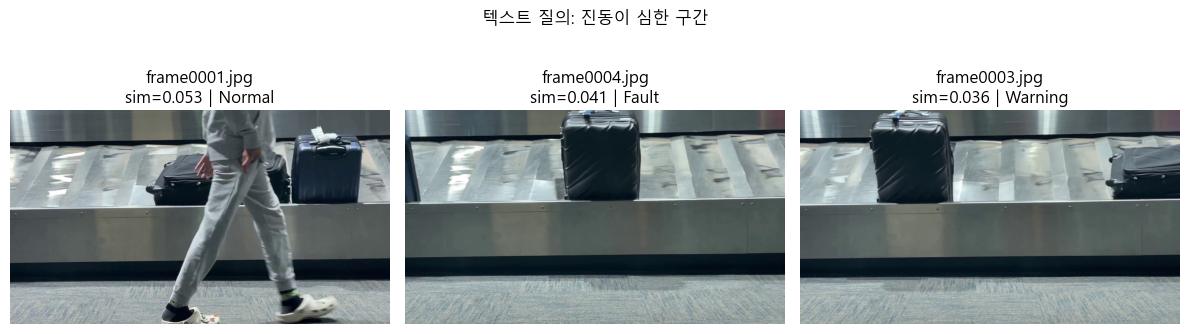

,frame,similarity,status,temp,vibration
0,frame0001.jpg,0.053,Normal,38.2,0.08
1,frame0004.jpg,0.041,Fault,48.8,0.45
2,frame0003.jpg,0.036,Warning,45.3,0.31


In [11]:
def equipment_image_qa(
    question: str | None = None,
    query_image: str | Path | None = None,
    top_k: int = 4,
    show_plot: bool = True,
):
    """설비 이미지 기반 질의응답 검색 헬퍼."""
    if query_image is not None:
        path = Path(query_image)
        if not path.is_absolute():
            path = FRAMES_DIR / path.name
        hits = search_by_image(encoder, store, path, top_k=top_k)
        title = f"이미지 질의: {path.name}"
    elif question:
        hits = search_by_text(encoder, store, question, top_k=top_k)
        title = f"텍스트 질의: {question}"
    else:
        raise ValueError("question 또는 query_image 중 하나를 지정하세요.")

    if show_plot:
        df = plot_search_hits(hits, title=title)
    else:
        rows = []
        for hit in hits:
            s = hit.get("sensor", hit["metadata"])
            rows.append({
                "frame": s.get("frame"),
                "similarity": hit["similarity"],
                "status": s.get("status"),
            })
        df = pd.DataFrame(rows)
    return {"hits": hits, "results": df}


demo = equipment_image_qa(question="진동이 심한 구간", top_k=3)
display(demo["results"])


## 요약

| 실습 | 내용 |
|------|------|
| **데이터 탐색** | 설비 프레임 + sensor.csv 상태 분포 |
| **텍스트 질의** | 자연어 → SigLIP2 → ChromaDB 검색 |
| **이미지 질의** | 참조 설비 이미지 → 유사 프레임 검색 |
| **직접 VQA** | 단일 프레임 + Qwen3-VL 답변 |
| **Visual RAG** | 검색 + 센서 + Qwen 종합 (`/analyze`) |
| **교차 검증** | 시각 유사도 vs 센서 Fault/Warning |
| **시나리오** | 이상 탐지·과열·유사 이력·Fault 비교 |

**핵심**: 설비 이미지 VQA는 **텍스트 질의**와 **이미지 질의**를 SigLIP2 **공유 임베딩**으로 처리하고,
Qwen3-VL이 **시각·센서 근거**로 답을 생성합니다.

### 실습 시리즈

| 노트북 | 주제 |
|--------|------|
| 01 | CLIP + ChromaDB + Qwen3-VL 기초 |
| 02 | 컨베이어 Visual RAG + 센서 |
| 03 | 분석 벡터 DB + FastAPI |
| 04 | Streamlit 시각 질의응답 서비스 |
| **05** | **설비 이미지 기반 질의응답 실습** |
